In [3]:
# Install if needed
%pip install pandas numpy matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Load dataset
df = pd.read_csv("/Users/bhargavram/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [9]:
bins = [0,12,24,48,72]
labels = ['0-12','12-24','24-48','48+']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

In [10]:
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [11]:
contract_churn = df.groupby('Contract')['Churn'].mean()*100
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


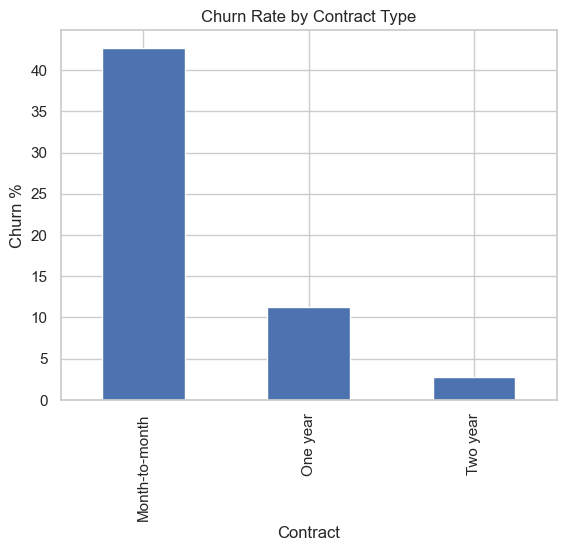

In [12]:
contract_churn.plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn %")
plt.show()

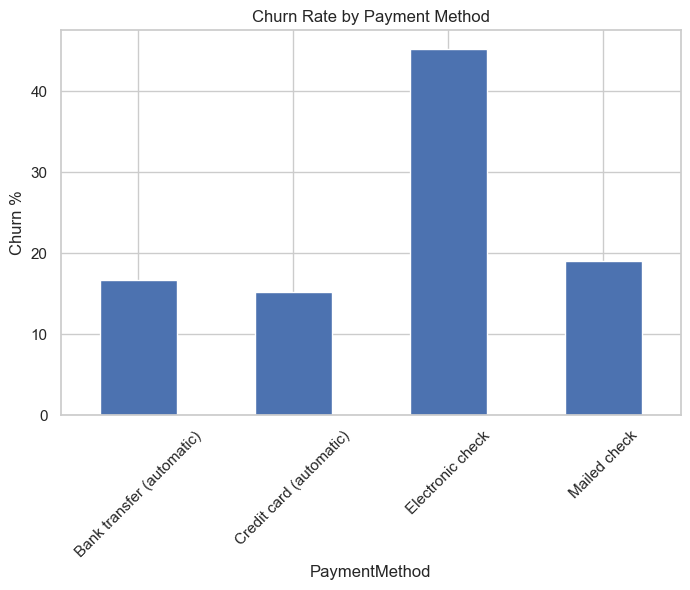

In [13]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean()*100
payment_churn.plot(kind='bar', figsize=(8,5))
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn %")
plt.xticks(rotation=45)
plt.show()

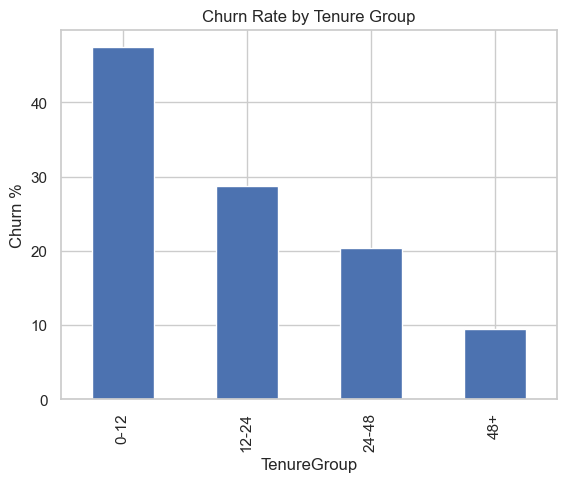

In [14]:
tenure_churn = df.groupby('TenureGroup')['Churn'].mean()*100
tenure_churn.plot(kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn %")
plt.show()

In [15]:
print("Average Tenure:", df['tenure'].mean())

Average Tenure: 32.37114865824223


In [16]:
print("Avg Tenure (Churned):", df[df['Churn']==1]['tenure'].mean())

Avg Tenure (Churned): 17.979133226324237


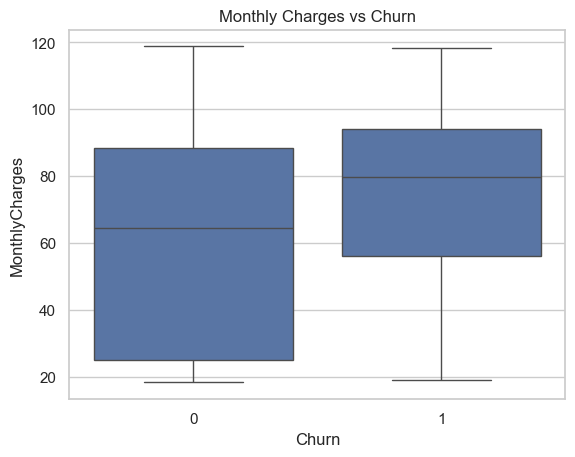

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [18]:
cohort = df.groupby('TenureGroup')['Churn'].agg(['count','sum'])
cohort['RetentionRate'] = (1 - cohort['sum']/cohort['count']) * 100
cohort

,count,sum,RetentionRate
TenureGroup,,,
0-12,2186,1037,52.561757
12-24,1024,294,71.289062
24-48,1594,325,79.611041
48+,2239,213,90.486824


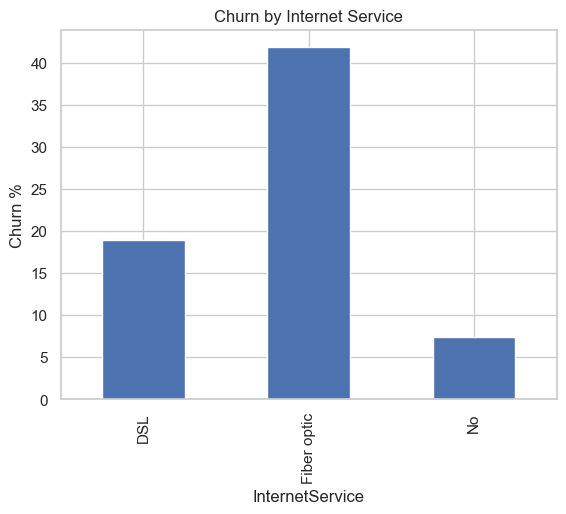

In [19]:
internet_churn = df.groupby('InternetService')['Churn'].mean()*100
internet_churn.plot(kind='bar')
plt.title("Churn by Internet Service")
plt.ylabel("Churn %")
plt.show()

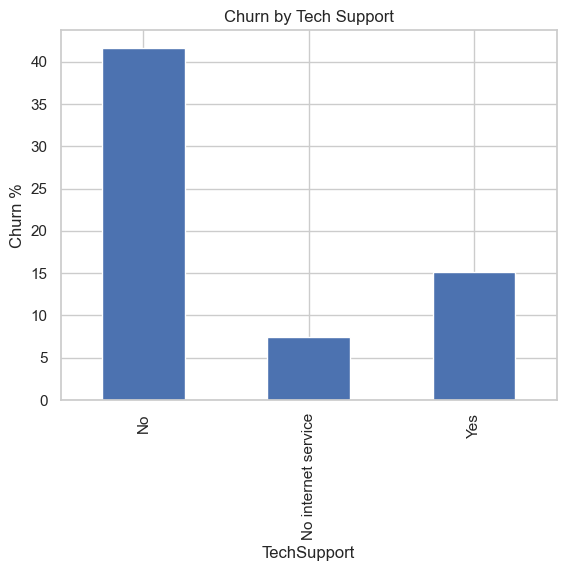

In [20]:
tech_churn = df.groupby('TechSupport')['Churn'].mean()*100
tech_churn.plot(kind='bar')
plt.title("Churn by Tech Support")
plt.ylabel("Churn %")
plt.show()

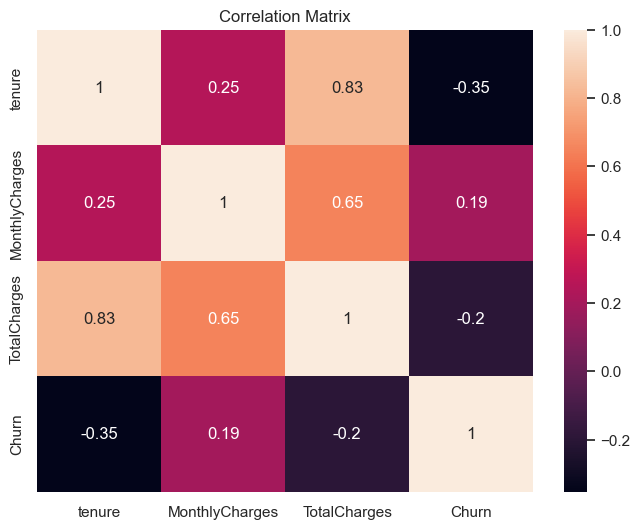

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [22]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] < 12) &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
]

high_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,0-12
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,0,0-12
39,8168-UQWWF,Female,0,No,No,11,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),97.85,1105.40,1,0-12
47,7760-OYPDY,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Electronic check,80.65,144.15,1,0-12


In [23]:
print("High Risk Customers:", len(high_risk))

High Risk Customers: 770


In [24]:
print("""
KEY INSIGHTS:
1. Month-to-month customers churn the most.
2. Customers in first 12 months have highest churn.
3. High monthly charge users are more likely to leave.
4. Customers without tech support churn more.
""")


KEY INSIGHTS:
1. Month-to-month customers churn the most.
2. Customers in first 12 months have highest churn.
3. High monthly charge users are more likely to leave.
4. Customers without tech support churn more.



In [25]:
%pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.3 MB/s eta 0:00:0000:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop duplicates
df = df.drop_duplicates()

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Drop ID column if exists
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Drop TenureGroup if previously created
if 'TenureGroup' in df.columns:
    df = df.drop(columns=['TenureGroup'])

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [29]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [32]:
# Clean Churn column properly
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()

df['Churn'] = df['Churn'].map({
    'yes': 1,
    'no': 0
})

# Check missing values
print(df['Churn'].isnull().sum())

7043


In [33]:
df.to_csv("cleaned_telco_churn.csv", index=False)

In [34]:
import os
os.getcwd()

'/Users/bhargavram/Downloads'

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/var/folders/g1/9y3t3gsx385227f74jnc_8z40000gn/T/ipykernel_59791/617195598.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [37]:
revenue_by_contract = df.groupby("Contract")["TotalCharges"].sum().reset_index()
revenue_by_contract

,Contract,TotalCharges
0,Month-to-month,5305861.500
1,One year,4468450.975
2,Two year,6297228.450


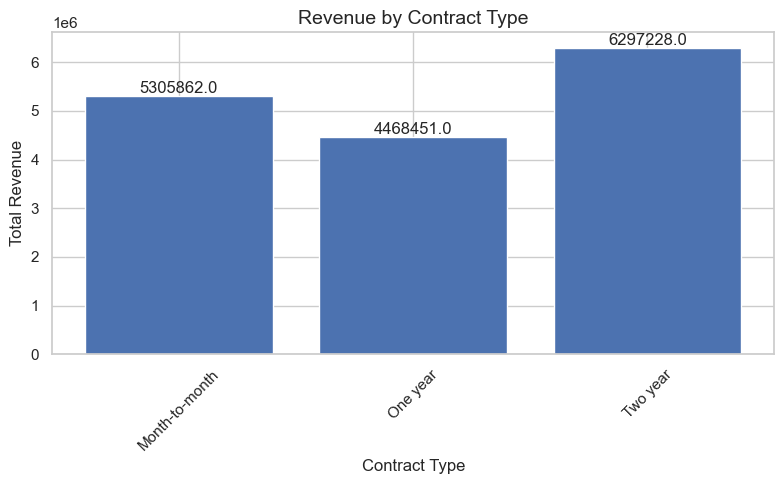

In [39]:
plt.figure(figsize=(8,5))
bars = plt.bar(revenue_by_contract["Contract"], 
               revenue_by_contract["TotalCharges"])

plt.title("Revenue by Contract Type", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Total Revenue")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, 
             round(yval, 0), 
             ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()